# Reported Crime Incidents By Year

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/vancouver_crime_clean.csv")

df.head()

,type,year,month,day,hour,minute,hundred_block,neighbourhood,x,y,date
0,Theft from Vehicle,2026,5,29,20,0,24XX BIRCH ST,Fairview,490288.3251,5.456857e+06,2026-05-29
1,Theft from Vehicle,2024,5,23,17,0,24XX BONNYVALE AVE,Victoria-Fraserview,495831.7011,5.451588e+06,2024-05-23
2,Theft from Vehicle,2025,4,8,0,23,24XX BURRARD ST,Kitsilano,489392.3161,5.456880e+06,2025-04-08
3,Theft from Vehicle,2024,2,9,17,0,24XX CAMBIE ST,Fairview,491636.2151,5.456792e+06,2024-02-09
4,Theft from Vehicle,2024,9,15,11,0,24XX CAMBIE ST,Fairview,491636.2151,5.456792e+06,2024-09-15


In [2]:
crime_by_year = df.groupby("year").size()
crime_by_year

year
2003    57253
2004    56473
2005    51685
2006    48490
2007    43308
2008    40640
2009    36830
2010    34499
2011    33342
2012    34356
2013    34599
2014    39183
2015    40219
2016    44094
2017    43196
2018    44243
2019    48152
2020    37519
2021    32191
2023    36719
2024    33792
2025    32495
2026    13731
dtype: int64

In [3]:
crime_by_type = df["type"].value_counts()
crime_by_type

type
Theft from Vehicle                                        250814
Other Theft                                               244675
Mischief                                                  115574
Offence Against a Person                                   81834
Break and Enter Residential/Other                          73577
Break and Enter Commercial                                 49201
Theft of Vehicle                                           45405
Theft of Bicycle                                           37791
Vehicle Collision or Pedestrian Struck (with Injury)       17378
Vehicle Collision or Pedestrian Struck (with Fatality)       425
Homicide                                                     335
Name: count, dtype: int64

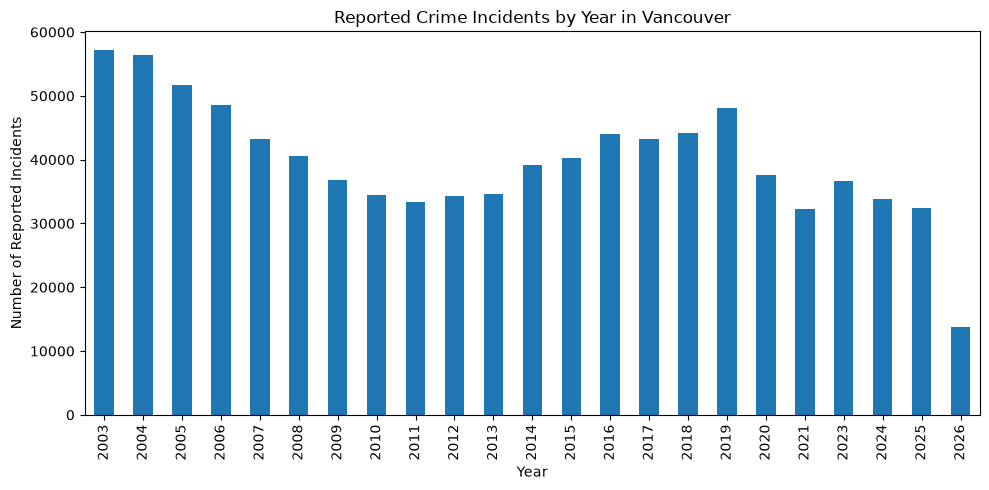

In [4]:
crime_by_year = df.groupby("year").size()

plt.figure(figsize = (10, 5))
crime_by_year.plot(kind = "bar")
plt.title("Reported Crime Incidents by Year in Vancouver")
plt.xlabel("Year")
plt.ylabel("Number of Reported Incidents")
plt.tight_layout()
plt.savefig("../results/figures/incidents_by_year.png", dpi = 300)
plt.show()

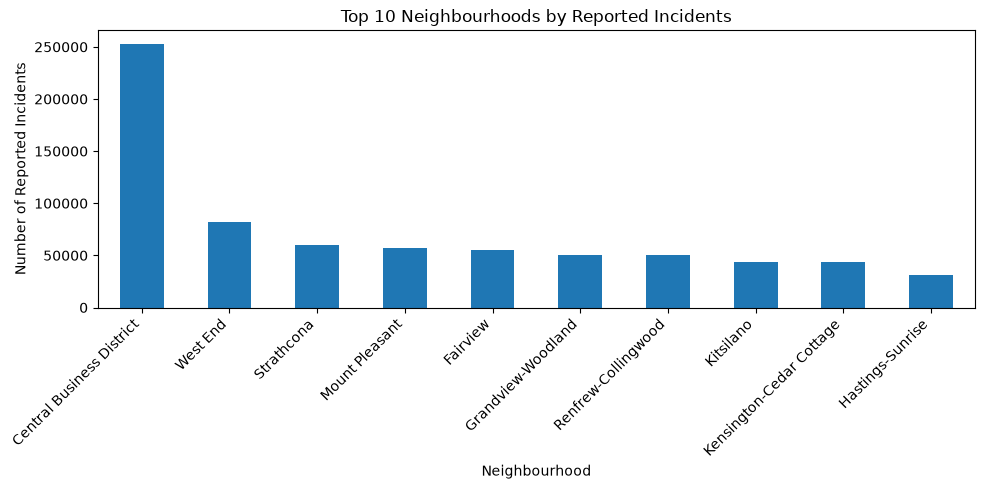

In [5]:
top_neighbourhoods = df["neighbourhood"].value_counts().head(10)

plt.figure(figsize = (10, 5))
top_neighbourhoods.plot(kind = "bar")
plt.title("Top 10 Neighbourhoods by Reported Incidents")
plt.xlabel("Neighbourhood")
plt.ylabel("Number of Reported Incidents")
plt.xticks(rotation = 45, ha = "right")
plt.tight_layout()
plt.savefig("../results/figures/top_neighbourhoods.png", dpi = 300)
plt.show()

Top 10 Neighbourhoods & Their Crime Composition

In [6]:
top10_df = df[df["neighbourhood"].isin(top_neighbourhoods.index)].copy()

In [13]:
# crime table of type x neighbourhood
crime_table = (
    top10_df
    .groupby(["neighbourhood", "type"])
    .size()
    .unstack(fill_value = 0)
)

# adds total and sorts
crime_table["total"] = crime_table.sum(axis=1)
crime_table = crime_table.sort_values("total", ascending=True)

crime_table.head()

type,Break and Enter Commercial,Break and Enter Residential/Other,Homicide,Mischief,Offence Against a Person,Other Theft,Theft from Vehicle,Theft of Bicycle,Theft of Vehicle,Vehicle Collision or Pedestrian Struck (with Fatality),Vehicle Collision or Pedestrian Struck (with Injury),total
neighbourhood,,,,,,,,,,,,
Hastings-Sunrise,1293,3919,14,4474,2367,5606,8790,601,2907,22,942,30935
Kensington-Cedar Cottage,1789,4973,23,5778,3827,9963,10965,1371,3386,27,1197,43299
Kitsilano,2807,5167,7,5284,1802,9738,12297,3462,2651,23,738,43976
Renfrew-Collingwood,1770,5078,26,5719,4149,15884,11901,702,3548,21,1220,50018
Grandview-Woodland,3015,5309,20,7465,6549,10969,10750,2020,3797,21,901,50816


In [18]:
# keeps top 5 crime types and reduce the rest into "Other"
type_only = crime_table.drop(columns = "total") # (drop total column to do this)
top_types = type_only.sum(axis = 0).sort_values(ascending = False).head(5).index

crime_table_reduced = type_only[top_types].copy()
crime_table_reduced["Other"] = type_only.drop(columns = top_types).sum(axis = 1)
crime_table_reduced["total"] = crime_table_reduced.sum(axis = 1)
crime_table_reduced.head()

type,Other Theft,Theft from Vehicle,Mischief,Offence Against a Person,Break and Enter Residential/Other,Other,total
neighbourhood,,,,,,,
Hastings-Sunrise,5606,8790,4474,2367,3919,5779,30935
Kensington-Cedar Cottage,9963,10965,5778,3827,4973,7793,43299
Kitsilano,9738,12297,5284,1802,5167,9688,43976
Renfrew-Collingwood,15884,11901,5719,4149,5078,7287,50018
Grandview-Woodland,10969,10750,7465,6549,5309,9774,50816


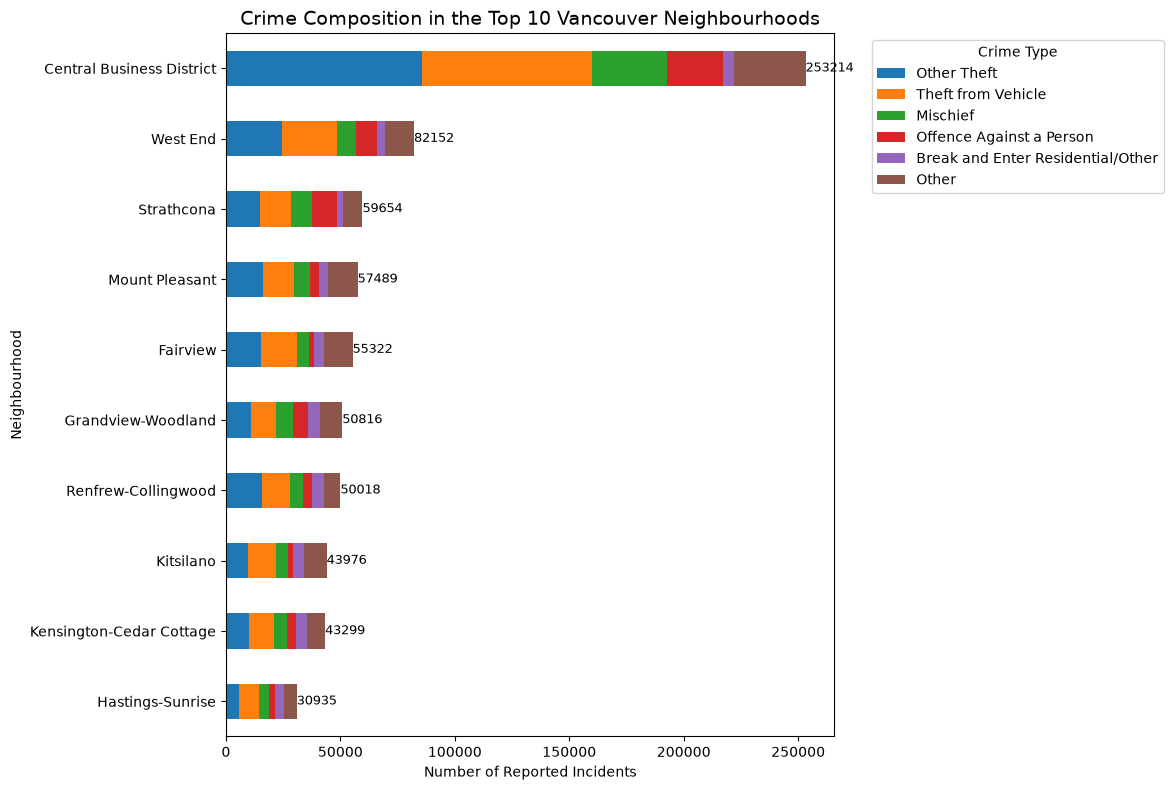

In [20]:
# plotting data
plot_data = crime_table_reduced.drop(columns = "total")

fig, ax = plt.subplots(figsize = (12, 8))

plot_data.plot(
    kind = "barh",
    stacked = True,
    ax = ax
)

ax.set_title("Crime Composition in the Top 10 Vancouver Neighbourhoods", fontsize = 14)
ax.set_xlabel("Number of Reported Incidents")
ax.set_ylabel("Neighbourhood")

for i, total in enumerate(crime_table_reduced["total"]):
    ax.text(total + 5, i, str(total), va = "center", fontsize=9)

plt.legend(title = "Crime Type", bbox_to_anchor=(1.05, 1), loc = "upper left")
plt.tight_layout()
plt.savefig("../results/figures/top10_neighbourhood_crime_composition.png", dpi = 300, bbox_inches = "tight")
plt.show()